# TD 3 : Intervalle de confiance 

Christelle Gonindard et Matthias Grenié

<div class="alert alert-info">

## Objectifs

- Comprendre la notion d'intervalle de confiance
- Identifier les conditions d'application pour calculer un intervalle de confiance
- Utiliser deux méthodes, une graphique et une statistique, pour vérifier la normalité d'un échantillon
- Calculer et interpréter des intervalles de confiance à l'aide d'une fonction fournie

</div>

## 1. Présentation des données

Un clinicien évalue l’intensité de la dépression sur l’échelle de Hamilton qui varie de 0 (non
déprimé) à 56 (très déprimé), chez 100 patients souffrant d’un Episode Dépressif Majeur (EDM).
On veut savoir si l’acupuncture améliore l’évolution de la dépression. Pour cela, 100 malades
de même état dépressif (même score de Hamilton) sont répartis en 2 groupes de 50 par tirage
au sort. Le groupe I a reçu uniquement le traitement pharmacologique et le groupe II a reçu le
traitement pharmacologique associé à de l’acupuncture.

Le jeu de données contient les variables suivantes en colonne :
- `hamilton_g1` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 1 ;
- `hamilton_g2` : Les scores de Hamilton, après 8 mois de traitement pour le groupe 2 ;
- `age_g1` : l’âge des patients du groupe 1 ;
- `age_g2` : l’âge des patients du groupe 2 ;
- `poids_g1` : le poids des patients du groupe 1 ;
- `poids_g2` : le poids des patients du groupe 2 ;
- `sexe_g1` : le sexe des patients du groupe 1 (`"F"` : femme, `"H"` : homme) ;
- `sexe_g2` : le sexe des patients du groupe 2 (`"F"` : femme, `"H"` : homme) ;
- `urbanisation_g1` : le niveau d’urbanisation dans lequel vivent les patients du groupe 1 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé) ;
- `urbanisation_g2` : le niveau d’urbanisation dans lequel vivent les patients du groupe 2 (`"A"` : rural, `"B"` : urbanisation modéré, `"C"` : fortement urbanisé).

Les données sont contenues dans le fichier texte nommé `depression.txt` qui se trouve dans le dossier `data`. Le chemin d'accès complet du fichier est donc `data/depression.txt`.

In [1]:
depression = read.table("data/depression.txt", header = TRUE)

# Afficher le début du contenu du fichier de données 
head(depression)

,hamilton_g1,hamilton_g2,urbanisation_g1,urbanisation_g2,age_g1,age_g2,poids_g1,poids_g2,sexe_g1,sexe_g2
,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,43,25,B,B,57,48,74,93,F,H
2,29,29,A,B,37,41,95,92,H,H
3,34,18,A,A,7,30,84,86,H,H
4,39,23,A,A,37,41,104,81,H,H
5,40,24,B,A,15,30,92,74,H,F
6,41,25,B,B,45,45,85,98,H,H


## 2. Rappel de cours : Intervalle de confiance

**Pourquoi calculer un intervalle de confiance** ?


L’estimation a pour objectif de déterminer les valeurs inconnues des paramètres de la
population (proportion, moyenne, variance) à partir des données de l’échantillon . C’est
une fonction des observations de l’échantillon dont la valeur sera utilisée en lieu et place
de la valeur vraie du paramètre. La valeur prise par le paramètre sur un échantillon donné
est appelée une estimation. L’**estimateur** est une **variable aléatoire** avec une **moyenne**
et une **variance**.

***Lorsque l’on passe d’un échantillon à un autre, l’estimateur reste le même (par exemple la moyenne) mais sa valeur varie, comme le montre l’exemple ci-dessous sur les deux échantillons de 100 vaccins, il y a deux estimations de la fréquence de vaccins non conforme : 5% pour le groupe A et 3% pour le groupe B.***

Exemple : 
Estimation de la fréquence de vaccins non-conformes dans deux échantillons différents A et B de la même série de vaccins.

<img src="figures/TD3_1.jpeg" />


La valeur de l’estimation fluctue en fonction de l’échantillonnage. Les méthodes d’estimation
ponctuelles ne portent que sur les données d’un échantillon, or dans une population,
il est possible de choisir différents échantillons :

<img src="figures/TD3_2.jpeg" />

Il est donc impossible d’obtenir la véritable valeur moyenne dans la population étudiée, on ne peut obtenir que des estimations sur des échantillons. De plus, l’estimation d’une moyenne à partir d’un échantillon ne présente pas grand intérêt si on n’a aucune idée de la précision de l’estimation obtenue. Aussi, on est conduit à rechercher un intervalle dans lequel il y a de bonnes chances que se trouve la vraie valeur de la moyenne. On procède alors à une estimation par intervalle de confiance à un niveau de confiance que l’on se fixe $(1-\alpha)\%$.

$$ IC_{ (1-\alpha)\%} = [\text{Borne}_{\text{inférieure}}~;~\text{Borne}_{\text{supérieure}}]$$

Les bornes de l’intervalle de confiance dépendent de l’échantillon étudié. Une infinité
d’intervalles de confiance peuvent être calculés à partir d’une infinité d’échantillons.

<img src="figures/TD3_3.jpeg" />

**Note importante sur l'interprétation d'un intervalle de confiance** : un intervalle de confiance à $X\%$ ne signifie pas que l'intervalle va réellement contenir la vraie valeur de la moyenne $X\%$ du temps mais que si l'on prenait 100 échantillons de la même population et que l'on construisait 100 intervalles de confiance, alors $X\%$ d'entre eux contiendraient la vraie valeur de la moyenne.

## 3. Calcul de l'intervalle de confiance

**Question du TD : Quel est l’intervalle de confiance de la moyenne des scores de Hamilton du groupe 1 pour les individus de sexe féminin ?**

### 3.1 Construction du jeu de données qui permet de répondre à la question

La réponse à cette question demande en premier :
- de construire un jeu de données contenant l’ensemble des scores de Hamilton du groupe 1 pour les individus de sexe féminin.
- d'afficher la taille de l'échantillon (on peut utiliser la fonction `length()`, longueur en Anglais pour obtenir la taille de l'échantillon,
  **/!\\ cela s'écrit lenGTH et pas lenTGH ou autre variation /!\\**) 
- de tracer l'histogramme de ces scores
- de tracer le boxplot de ces scores

[1] 43 37 38 40 37 41 43 47 46 42 44

[1] 11

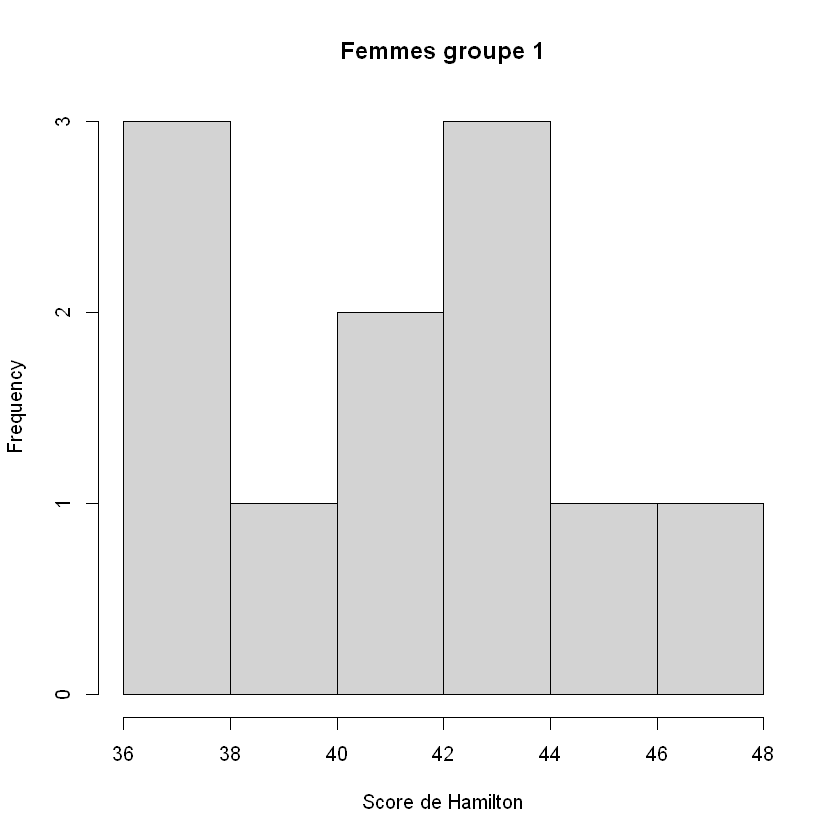

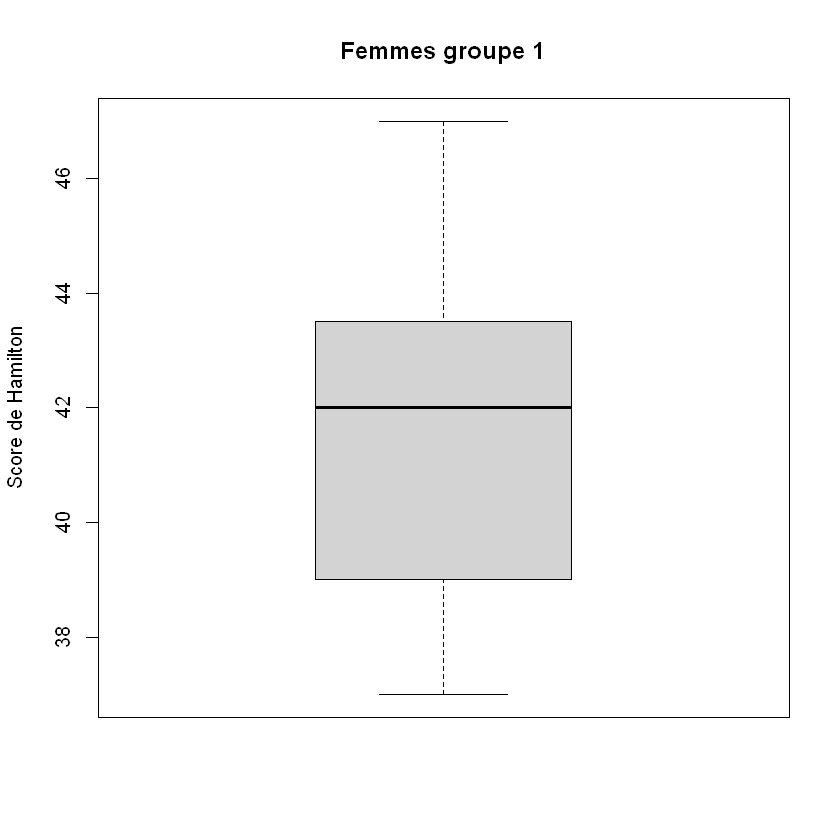

In [2]:
# Extraction des données
femme_g1 <- depression$hamilton_g1[depression$sexe_g1 == "F"]

# Affichage des données extraites
femme_g1

# taille de l'échantillon
length(femme_g1)

# tracer l'histogramme 
hist(femme_g1, main = "Femmes groupe 1", xlab = "Score de Hamilton")

# tracer du boxplot
boxplot(femme_g1, main = "Femmes groupe 1", ylab = "Score de Hamilton")

### 3.2 Calcul des paramètres de l'échantillon

Décrire l'échantillon en calculant :
- la moyenne 
- la variance 
- l'écart type 
- afficher le résumé statistique

Commenter vos résultats

In [3]:
mean(femme_g1)
var(femme_g1)
sd(femme_g1)
summary(femme_g1)

[1] 41.63636

[1] 11.65455

[1] 3.413875

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  37.00   39.00   42.00   41.64   43.50   47.00 

**Commentaire :**

La moyenne du score de Hamilton des femmes du groupes G1 est de 41.6, elle a été
obtenue à partir d’un petit échantillonnage de seulement 11 patientes avec un écart-type
d’environ 3.5 année. Cette estimation de la moyenne ne représente donc pas la valeur
exacte du score de Hamilton pour toutes les femmes qui auraient reçu le traitement mais
seulement une estimation. Si nous échantillonnons dans les mêmes conditions un autre
groupe de femmes, la valeur de la moyenne changerait sensiblement. Il est donc important
de calculer l’intervalle de confiance afin d’avoir une idée bornes entre lesquelles se
situe la moyenne théorique en fixant notre seul d’erreur.

<div class="alert alert-danger" role="alert">

**Conditions d’application :**
- Si la taille de l’échantillon est grande ($n \geq 30$) : pas de condition d’application -> on peut calculer l'intervalle de confiance
- Si la taille de l’échantillon est petite ($n < 30$) : il faut que les données suivent une loi normale

</div>

### 3.3 Vérification de la Normalité de l'échantillon

#### Méthode graphique : diagramme quantile-quantile

Une méthode graphique permet de vérifier cette normalité en traçant les quantiles de
l’échantillon en fonction des quantiles d’une loi normale. L'idée est de calculer les quantiles théoriques qu'auraient une loi normale de même moyenne et de même écart-type que les données observées, on les compare aux quantiles observés. Sous l’hypothèse de normalité les points doivent s’aligner sur une droite. Si les points sont proches d'une droite, notre distribution observée suit donc une loi normale.

Sur R, pour faire un diagramme quantile-quantile de loi Normale on doit d'abord utiliser la fonction `qqnorm()` sur le vecteur de données (pour ***q**uantile-**q**uantile of a **norm**al distribution), puis `qqline()` sur le même vecteur pour obtenir la ligne droite.

*Représentez le diagramme quantile-quantile pour les scores de Hamilton des femmes du groupe 1*

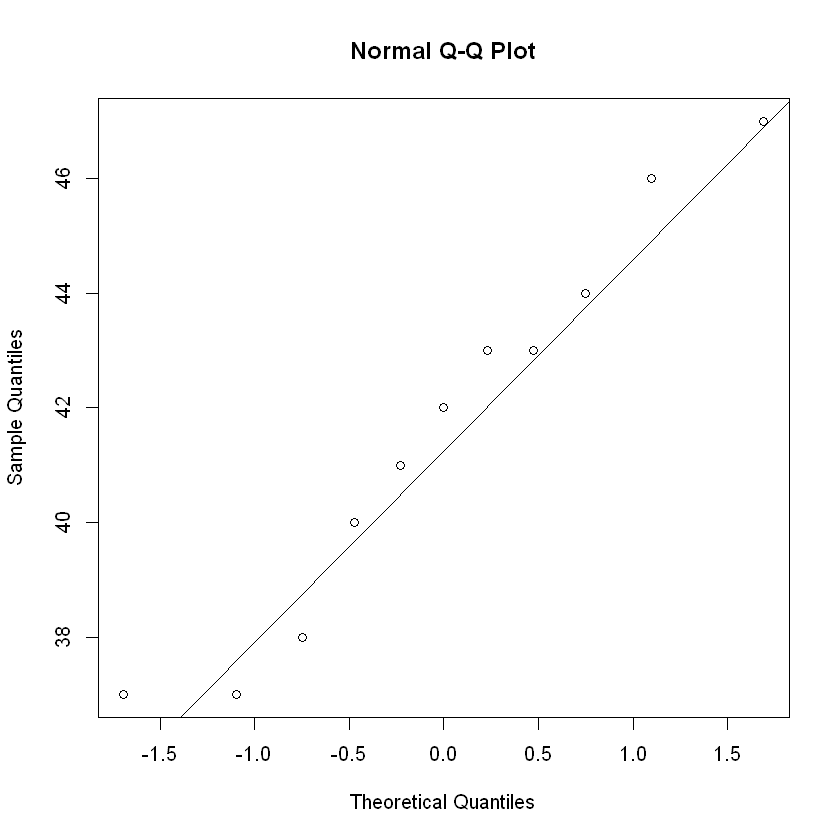

In [4]:
qqnorm(femme_g1)
qqline(femme_g1)

**Interprétation** :

Globalement les quantiles observés de l’échantillon (points) s’alignent bien avec la droite
des quantiles théoriques de la loi normale. Il semblerait que les données suivent bien une
loi normale. Si ils ne s’alignent pas parfaitement c’est dû à plusieurs facteurs : la faible
taille des échantillonnages, la variabilité des données...

#### Test de Normalité

Il est aussi possible d’avoir une approche basée sur un test numérique, par exemple en
calculant la variable $W$ du test de Shapiro-Wilk. Ce test statistique permet de vérifier la normalité d'une échantillon en calculant la valeur $W$ et en la comparant à une valeur théorique. Si la valeur observée est proche de la valeur théorique attendue, alors on conclura que notre distribution suit une loi Normale, si on observe un grand écart, alors on conclura que notre échantillon ne suit pas une loi normale.

Voici les hypothèses de Shapiro-Wilk :

<div class="alert alert-warning" role="alert">

## Hypothèses

**Hypothèse nulle (notée H0)** : la distribution de notre échantillon suit une loi normale.  
**Hypothèse alternative (notée H1)** : la distribution de notre échantillon ne suit pas une loi normale.

</div>

Pour réaliser ce test sur R, il faut utiliser la fonction `shapiro.test()` qui prend comme argument le vecteur de valeurs de l'échantillon à tester.

In [5]:
shapiro.test(femme_g1)


	Shapiro-Wilk normality test

data:  femme_g1
W = 0.94764, p-value = 0.614


**Conclusion** :


On observe que p = 0.61 > alpha = 0.05, donc on ne peut pas rejeter l’hypothèse H0
donc la distribution des scores de Hamilton des femmes du groupe 1 suit une loi normale.

Et donc, les conditions d’application pour calculer un intervalle de confiance sont vérifiées, on peut le calculer.


### 3.4 Calcul de l'intervalle de confiance

La moyenne $m$ que nous avons calculée à partir de notre échantillon est une estimation de
la moyenne $\mu$ du score de Hamilton de la population des femmes du groupe 1. $m$ fluctue en fonction de
l’échantillon que nous analysons (= si l'on choisissait un autre échantillon, on obtiendrait une autre valeur de $m$). C’est donc une variable aléatoire se distribuant selon
une loi normale d’espérance $E[m]$ et de variance $V[m]$ si le score de Hamilton se distribue
lui même selon une loi normale avec une moyenne $\mu$ et une variance $\sigma ^2$.

Pour un échantillon de taille $n$ et pour un intervalle de confiance à un seuil $\alpha$ donnée (souvent 95%) se calcule avec la formule suivante :

$$\text{IC} = \mu \pm Z(1-\frac{\alpha}{2}) \frac{\sigma}{\sqrt{n}}$$

avec $Z(1-\frac{\alpha}{2})$ le quantile de la loi de Student d'ordre $1 - \frac{\alpha}{2}$ de la loi de Student à $n − 1$ degrés de liberté.


Il n'existe pas de fonction en **R** permettant de calculer directement un intervalle de confiance.
Comme ce calcul nécessite plusieurs opérations nous vons proposons une fonction créée pour l'occassion s'appelant `CI()` (pour ***C**onfidence **I**nterval*, intervalle de confiance en anglais) vous permettant de le faire en une simple ligne.
La fonction comme premier argument le vecteur contenant les valeurs sur lesquelles calculer l'intervalle de confiance, en deuxième argument elle prend le pourcentage de confiance associée à l'intervalle, par exemple 0.95 pour un intervalle à 95%.

**Vous devez exécuter le bloc de code ci-dessous avant de pouvoir vous servir de la fonction.  
Il faudra rajouter cette fonction au début de chaque nouveau TD pour vous en servir.**

In [6]:
CI <- function(x, confidence){
    alpha = 1 - confidence
    mu = mean(x)
    sigma = sd(x)
    n = length(x)
    CI_inf = mu - (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI_sup = mu + (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI = c(inf = CI_inf, sup = CI_sup) 
    return(CI)
}

On peut maintenant utiliser la fonction sur notre série de données

In [7]:
# Intervalle de confiance donné par défaut à 95%
CI(femme_g1, 0.95)

inf      sup 
39.34289 43.92984

**Interprétation** :

La vraie moyenne se situe donc entre les bornes 39 et 44 au seuil 95%

*Application : calculer l'intervalle de confiance à 98% du score hamilton des femmes du groupe 1*

In [8]:
# Intervalle de confiance pour modifier le seuil 
CI(femme_g1, 0.98)

inf      sup 
38.79155 44.48117

**Interprétation** :

Cette fois, les bornes de l’intervalle de confiance sont : 38 et 45 au seuil 98%.

<div class="alert alert-success">

## En résumé

Dans cette séance :

- Nous avons rappelé la théorie des intervalles de confiance
- Nous avons rappelé les conditions d'application à vérifier avant de les calculer : si $n \geq 30$ pas de conditions à vérifier, sinon il faut vérifier la normalité de l'échantillon
- Nous avons appris à utiliser deux méthodes pour vérifier la normalié d'un échantillon : (1) la méthode graphique avec le diagramme quantile-quantile avec `qqnorm()` et `qqline()`, (2) la méthode statistique avec le test de Shapiro-Wilk en utilisant `shapiro.test()`
- Nous avons appris à interpréter les résultats d'un test statistique en utilisant les p-values et à conclure sur les hypothèses
- Nous avons vu comment calculer un intervalle de confiance avec la fonction particulière `CI()` et comment l'interpréter

</div>

## 4. Exercices d'application

### 4.1 Exercices d'entraînement (à faire en cours si possible)

#### Exercice 1

1. Calculer l’intervalle de confiance du score de Hamilton des hommes puis des femmes pour le groupe 1, en vérifiant les conditions d’application (au seuil 95%)
2. Calculer l’intervalle de confiance du score de Hamilton des hommes puis des femmes pour le groupe 2, en vérifiant ces conditions d’application (au seuil 95%)
3. Qu’en concluez-vous ?

In [9]:
# Question 1 : Calculer l’intervalle de confiance du score de Hamilton des hommes 
# puis des femmes pour le groupe 1, en vérifiant les conditions d’application (au seuil 95%)

# femme déjà fait précédemment
# IC femme G1 = 39 et 44 au seuil 95%

# homme 
homme_g1 = depression$hamilton_g1[depression$sexe_g1 == "H"]

length(homme_g1)

## pas de condition d'application

CI(homme_g1, 0.95)

# IC homme G1 = 36 et 40 au seuil 95%


# Question 2 : Calculer l’intervalle de confiance du score de Hamilton des hommes puis des femmes 
# pour le groupe 2, en vérifiant ces conditions d’application (au seuil 95%)

# femme 
femme_g2 = depression$hamilton_g2[depression$sexe_g2=="F"]

length(femme_g2)

shapiro.test(femme_g2)


CI(femme_g2,0.95)

# IC femme G1 = 18 et 31 au seuil 95%

# homme 
homme_g2=depression$hamilton_g2[depression$sexe_g2=="H"]

length(homme_g2)

## pas de condition d'application

CI(homme_g2,0.95)

# IC homme G1 = 23 et 27 au seuil 95%


[1] 39

inf      sup 
36.35955 39.58917

[1] 5


	Shapiro-Wilk normality test

data:  femme_g2
W = 0.96258, p-value = 0.8258


inf      sup 
18.03322 31.56678

[1] 45

inf      sup 
23.00265 26.01958

Rapidement : 
- Groupe 2 moins dépressif aussi bien chez les hommes que les femmes, ce qui laisserait penser que l'accuponcture a un effet bénéfique
- Dans groupe 1 : homme moins dépressif que les femmes, dans le groupe 2 niveau dépression équilibré (attention aux faibles échantillonages qui agrandit les bornes de l'IC. 


#### Exercice 2

1. Extraire un sous jeu de données que l’on nommera U1 et qui contient les score de Hamilton du groupe 1 dans les zones faiblement urbanisées (c’est-à-dire `urbanisation_g1 == "A"`)
2. Calculer l’intervalle de confiance de U1, en vérifiant les conditions d’application (au seuil 95%)
3. Extraire un sous jeu de données que l’on nommera U2 et qui contient les score de Hamilton du groupe 1 dans les zones urbanisées (c’est-à-dire `urbanisation_g1 == "B"`)
4. Calculer l’intervalle de confiance de U2, en vérifiant les conditions d’application (au seuil 95%)
5. Qu’en concluez-vous ?

In [10]:
# 1. Extraire un sous jeu de données que l’on nommera U1 et qui contient les score de Hamilton du groupe 1 
# dans les zones faiblement urbanisées (c’est-à-dire urbanisation_g1=="A")

U1=depression$hamilton_g1[depression$urbanisation_g1=="A"]

# 2. Calculer l’intervalle de confiance de U1, en vérifiant les conditions d’application (au seuil 95%)

length(U1)

# n < 30 => condition d'application

shapiro.test(U1)

CI(U1,0.95)

# 3. Extraire un sous jeu de données que l’on nommera U2 et qui contient les score de Hamilton du groupe 
# 1 dans les zones urbanisées (c’est-à-dire urbanisation_g1=="B")

U2=depression$hamilton_g1[depression$urbanisation_g1=="B"]


# 4. Calculer l’intervalle de confiance de U2, en vérifiant les conditions d’application (au seuil 95%)

length(U2)

# n < 30 => condition d'application

shapiro.test(U2)

# On ne peut pas calculer l'intervalle de confiance au seuil 5%

[1] 24


	Shapiro-Wilk normality test

data:  U1
W = 0.94213, p-value = 0.182


inf      sup 
33.29038 35.62628

[1] 21


	Shapiro-Wilk normality test

data:  U2
W = 0.88686, p-value = 0.01962


### 4.2 Exercices supplémentaires

Ces exercices vous permettent de réviser les deux premiers TD. 

#### Exercice A

1. Extraire tableau de données que l'on nommera `g2_b` et qui contient les informations relatives au groupe 2 dans les zones  urbanisées (c’est-à-dire `urbanisation_g2 == "B"`).
2. Retirer de ce jeu de donnée l'individu le plus âgé.
   (*indice pour ce faire, il faut d'abord trouver la valeur maximum du poids, puis enlever cette valeur à partir des filtres*)
3. À partir de ce tableau `g2_b`, calculez la moyenne, la médiane, les quartiles et l'écart type du poids.
4. Extraire un sous-jeu de données que l’on nommera `g2_a` et qui contient les scores de Hamilton du groupe 2 dans les zones  urbanisées (c’est-à-dire `urbanisation_g2 == "A"`).
5. Retirer de ce jeu de donner la femme la plus légère.
   (*même indice que la question 2*)
6. A partir du tableau `g2_a`, calculez la moyenne, les quartiles et la variance de l'âge.
7. Pour `g2_b` et `g2_a`, calculez les intervalles de confiances du score Hamilton, en vérifiant les conditions d’application (au seuil 95%)
8. Qu’en concluez-vous ?


In [11]:
#1. Extraire tableau de données que l'on nommera U3 et qui contient les informations relatives au groupe 2 
# dans les zones  urbanisées (c’est-à-dire urbanisation_g2=="B").


g2_b =depression[depression$urbanisation_g2=="B",c(2,4,6,8,10)]

head(g2_b)

dim(g2_b)

#2. Retirer de ce jeu de donnée l'individu le plus âgé.

summary(g2_b)

g2_b = subset(g2_b, age_g2 != max(g2_b$age_g2))

dim(g2_b)

,hamilton_g2,urbanisation_g2,age_g2,poids_g2,sexe_g2
,<int>,<chr>,<int>,<int>,<chr>
1,25,B,48,93,H
2,29,B,41,92,H
6,25,B,45,98,H
7,27,B,41,75,H
9,27,B,47,83,H
13,26,B,29,85,H


[1] 26  5

  hamilton_g2    urbanisation_g2        age_g2         poids_g2     
 Min.   :25.00   Length:26          Min.   :13.00   Min.   : 74.00  
 1st Qu.:26.00   Class :character   1st Qu.:30.25   1st Qu.: 80.75  
 Median :28.00   Mode  :character   Median :39.50   Median : 86.00  
 Mean   :28.38                      Mean   :37.77   Mean   : 86.85  
 3rd Qu.:30.00                      3rd Qu.:46.00   3rd Qu.: 92.00  
 Max.   :36.00                      Max.   :55.00   Max.   :106.00  
   sexe_g2         
 Length:26         
 Class :character  
 Mode  :character  
                   
                   
                   

[1] 25  5

In [12]:
#3. A partir de ce tableau U3, calculez la moyenne, la médiane, les quartiles et l'écart type du poids.

summary(g2_b$poids_g2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  74.00   80.00   86.00   86.92   92.00  106.00 

In [13]:
#4. Extraire tableau de données que l'on nommera U4 et qui contient les informations relatives au groupe 2 
# dans les zones  urbanisées (c’est-à-dire urbanisation_g2=="A").

g2_a=depression[depression$urbanisation_g2 == "A", c(2,4,6,8,10)]

head(g2_a)

dim(g2_a)

summary(g2_a)

#5. Retirer de ce jeu de donner la femme la plus légère.
summary(g2_a$poids_g2[g2_a$sexe_g2 == "F"])
        
poids_min_femme=min(g2_a$poids_g2[g2_a$sexe_g2 == "F"])

poids_min_femme

g2_a = g2_a[g2_a$poids_g2 > poids_min_femme,]

dim(g2_a)

summary(g2_a)

,hamilton_g2,urbanisation_g2,age_g2,poids_g2,sexe_g2
,<int>,<chr>,<int>,<int>,<chr>
3,18,A,30,86,H
4,23,A,41,81,H
5,24,A,30,74,F
8,16,A,17,90,H
10,16,A,48,82,H
11,18,A,29,66,F


[1] 24  5

  hamilton_g2    urbanisation_g2        age_g2         poids_g2     
 Min.   :15.00   Length:24          Min.   :17.00   Min.   : 66.00  
 1st Qu.:18.00   Class :character   1st Qu.:30.00   1st Qu.: 80.50  
 Median :20.00   Mode  :character   Median :35.00   Median : 84.50  
 Mean   :20.38                      Mean   :35.92   Mean   : 85.96  
 3rd Qu.:23.25                      3rd Qu.:41.75   3rd Qu.: 91.75  
 Max.   :24.00                      Max.   :55.00   Max.   :104.00  
   sexe_g2         
 Length:24         
 Class :character  
 Mode  :character  
                   
                   
                   

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   66.0    69.5    73.0    71.0    73.5    74.0 

[1] 66

[1] 23  5

  hamilton_g2    urbanisation_g2        age_g2         poids_g2     
 Min.   :15.00   Length:23          Min.   :17.00   Min.   : 73.00  
 1st Qu.:18.50   Class :character   1st Qu.:30.50   1st Qu.: 81.50  
 Median :20.00   Mode  :character   Median :35.00   Median : 85.00  
 Mean   :20.48                      Mean   :36.22   Mean   : 86.83  
 3rd Qu.:23.50                      3rd Qu.:42.50   3rd Qu.: 92.50  
 Max.   :24.00                      Max.   :55.00   Max.   :104.00  
   sexe_g2         
 Length:23         
 Class :character  
 Mode  :character  
                   
                   
                   

In [14]:
#6. A partir du tableau U4, calculez la moyenne, les quartiles et la variance de l'âge.

summary(g2_a$age_g2)


#7. Pour U3 et U4, calculez les intervalles de confiances du score Hamilton, en vérifiant les conditions 
# d’application (au seuil 95%)

nrow(g2_b)

length(g2_a)


# n <30

shapiro.test(g2_b$hamilton_g2)
shapiro.test(g2_a$hamilton_g2)

# normalité pour h_3 mais pas pour h_4 => on peut calculer que l'IC de h_3

CI(g2_b$hamilton_g2,0.85)

#8. Qu’en concluez-vous ?

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  17.00   30.50   35.00   36.22   42.50   55.00 

[1] 25

[1] 5


	Shapiro-Wilk normality test

data:  g2_b$hamilton_g2
W = 0.92616, p-value = 0.07088



	Shapiro-Wilk normality test

data:  g2_a$hamilton_g2
W = 0.87583, p-value = 0.008301


inf      sup 
27.68703 29.35297

#### Exercice B

1. Quel est l'âge maximum et minimum de la femme appartenant au groupe 1 dans les zones  urbanisées et dont le poids est strictement inférieur au deuxième quartile.
2. Même question pour le groupe 2 dans les zones faiblement urbanisées et dont le poids le poids et supérieur ou égale au 8ème décile (un décile est un quantile à 10%, on peut le calculer avec la fonction `quantile(x, 0.8)`.
3. Représenter graphiquement l'âge en fonction du poids pour les individus du groupe 2.  
   (*indice vous pouvez le faire en utilisant la fonction `plot()` en précisant d'abord la variable de coordonnées sur l'axe des abscisses, puis celle sur l'axe des ordonnées*) 
4. Représenter graphiquement l'âge en fonction du poids pour les hommes du groupe 1.
5. Représenter graphiquement les boxplots représentant les âges dans les groupes 1 et 2 en séparant les hommes et les femmes.
6. Représenter graphiquement les boxplots représentant les poids dans les groupes 1 et 2 en séparant les hommes et les femmes.

Pensez à commenter vos graphiques

[1] 57 62 56 40 72 23

integer(0)

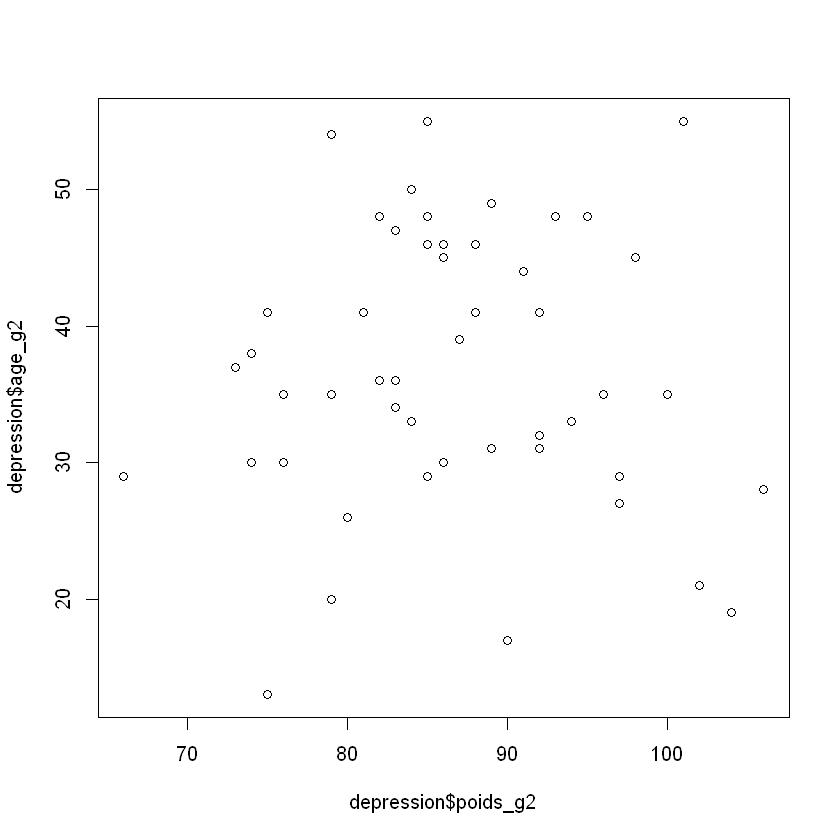

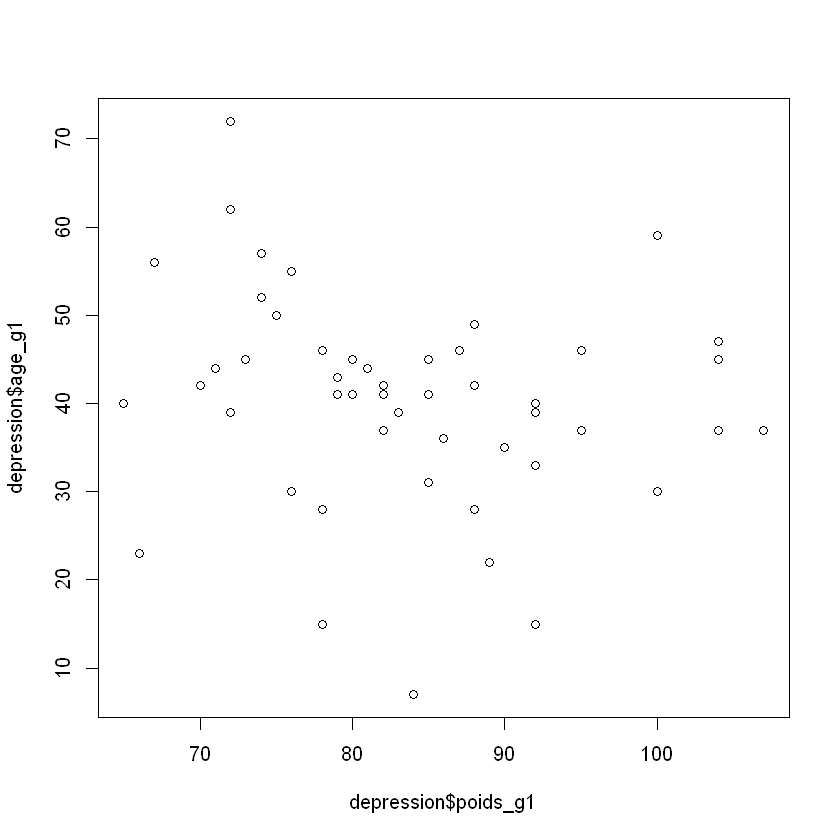

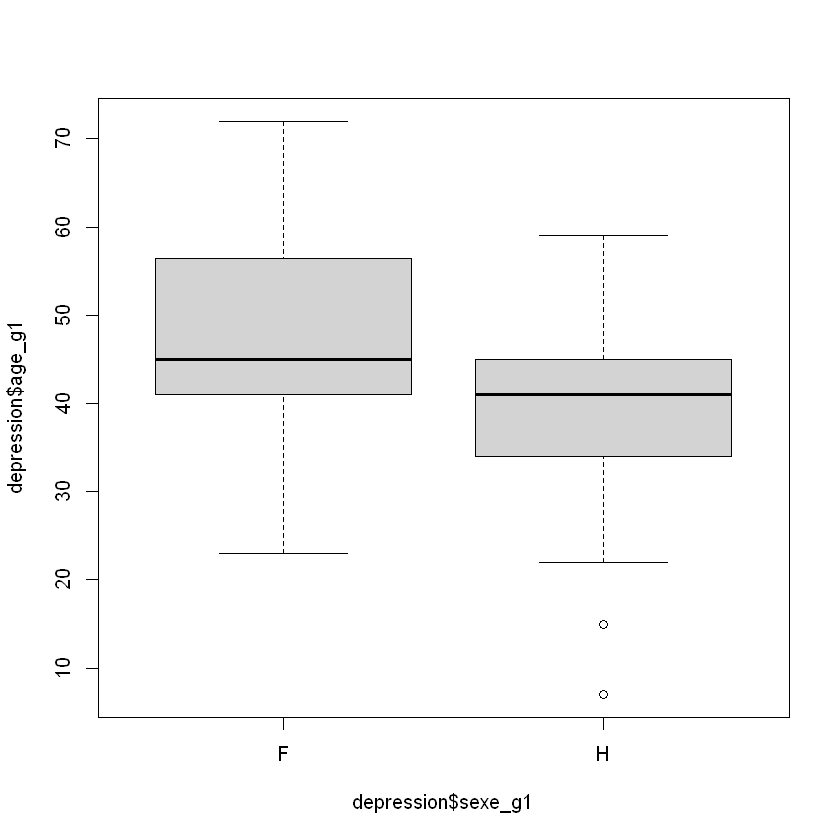

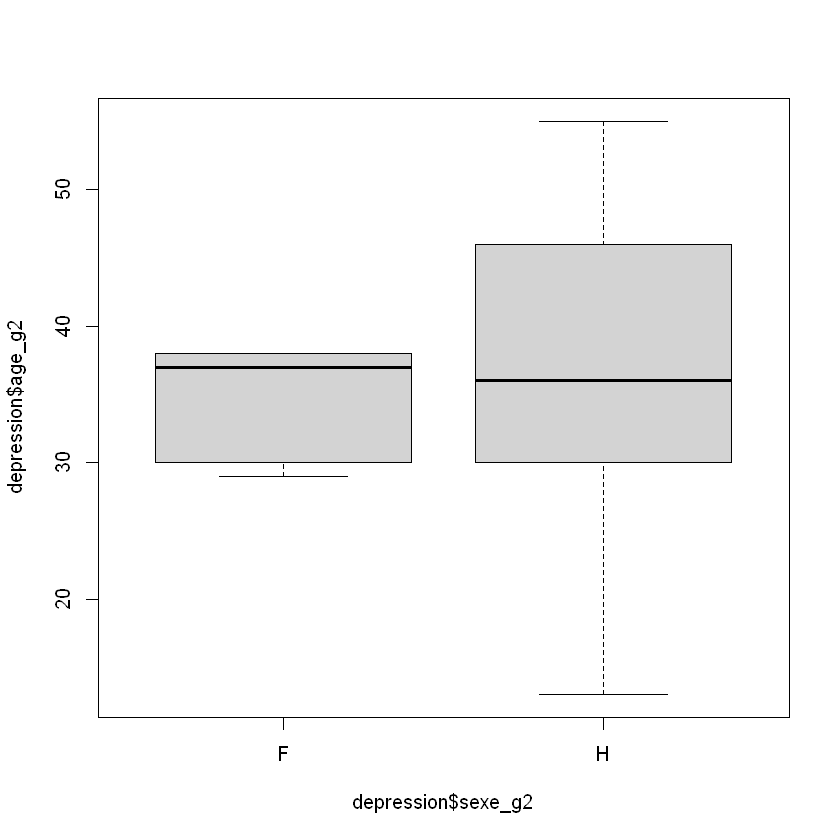

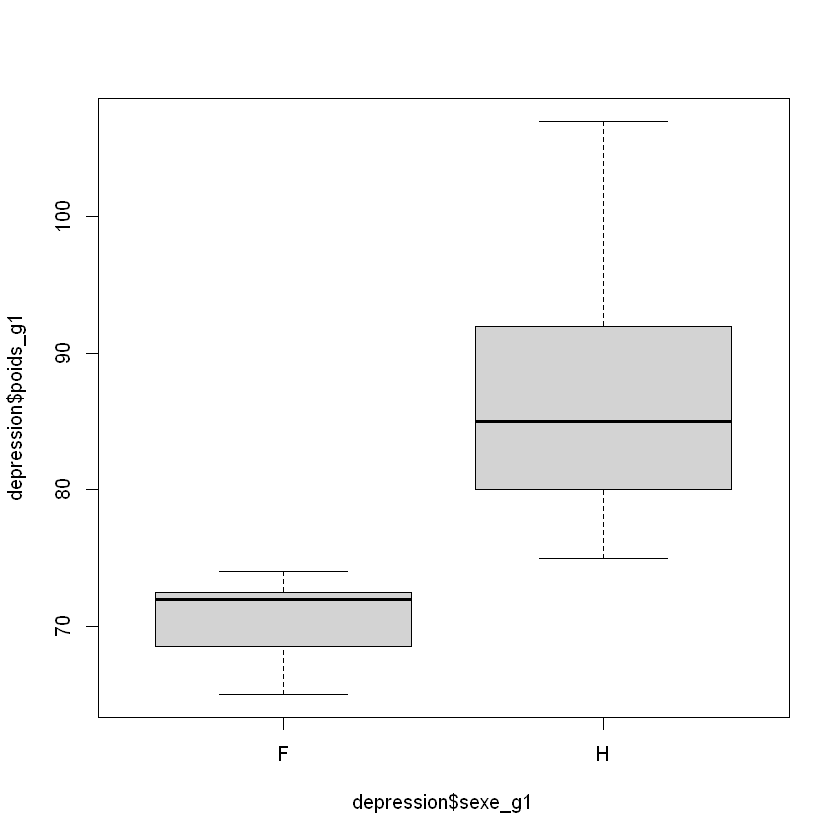

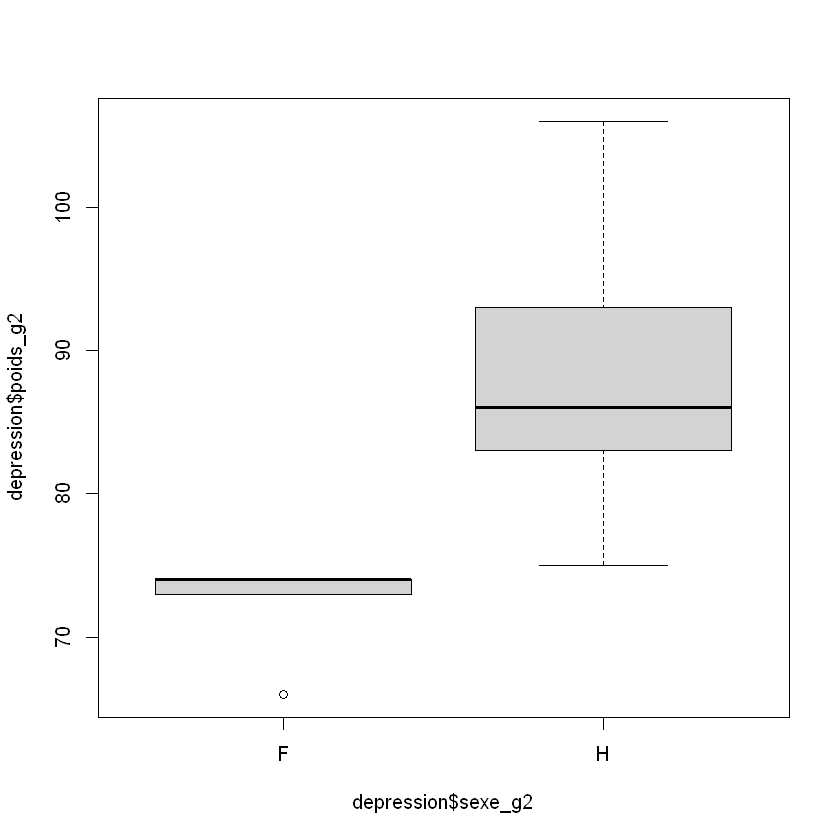

In [15]:
#1. Quel est l'âge maximum et minimum de la femme appartenant au groupe 1 dans les zones modérément 
# urbanisées et dont le poids est strictement inférieur au deuxième quartile.


z = depression$age_g1[
    depression$sexe_g1 == "F" &
    depression$urbanisation_g1 == "B" &
    depression$poids_g1 < median(depression$poids_g1)
]

z

#2. Même question pour le groupe 2 dans les zones faiblement urbanisées et dont le poids le poids 
# et supérieur ou égale au 7 déciles.

z2=depression$age_g2[
    depression$sexe_g2 == "F" &
    depression$urbanisation_g2 == "B" &
    depression$poids_g2 >= quantile(depression$poids_g2, 0.8)
]

z2
#3. Représenter graphiquement l'âge en fonction du poids pour les individus du groupe 2.

plot(depression$poids_g2,depression$age_g2)
#4. Représenter graphiquement l'âge en fonction du poids pour les hommes du groupe 1.
plot(depression$poids_g1,depression$age_g1)

#5. Représenter graphiquement les boxplots représentant les âges dans les groupes 1 et 2 en séparant les hommes et les femmes.

boxplot(depression$age_g1~depression$sexe_g1)

boxplot(depression$age_g2~depression$sexe_g2)

#6. Représenter graphiquement les boxplots représentant les poids dans les groupes 1 et 2 en séparant les hommes et les femmes.

boxplot(depression$poids_g1~depression$sexe_g1)

boxplot(depression$poids_g2~depression$sexe_g2)



#### Exercice C

On souhaite ici calculer des intervalles à 98%, le risque $\alpha$ pour le test est de 1%

1. reprenez les exercices 1 et 2 en calculant l'intervalle de confiance de l'âge.
2. reprenez les exercices 1 et 2 en calculant l'intervalle de confiance du poids. 

**I. Intervalles de confiances sur les données âges**

In [16]:
#### Exercice 1 

# Question 1 : Calculer l’intervalle de confiance des âges des hommes 
# puis des femmes pour le groupe 1, en vérifiant les conditions d’application (au seuil 95%)

# femme 
femme_g1=depression$age_g1[depression$sexe_g1 == "F"]

length(femme_g1)

shapiro.test(femme_g1)

CI(femme_g1, 0.98)

# homme 
homme_g1=depression$age_g1[depression$sexe_g1 == "H"]

length(homme_g1)

## pas de condition d'application

CI(homme_g1, 0.98)

# IC homme G1 = 36 et 40 au seuil 95%


# Question 2 : Calculer l’intervalle de confiance du score de Hamilton des hommes puis des femmes 
# pour le groupe 2, en vérifiant ces conditions d’application (au seuil 95%)

# femme 
femme_g2=depression$age_g2[depression$sexe_g2 == "F"]

length(femme_g2)

shapiro.test(femme_g2)


CI(femme_g2,0.98)

# IC femme G1 = 18 et 31 au seuil 95%

# homme 
homme_g2=depression$age_g2[depression$sexe_g2 == "H"]

length(homme_g2)

## pas de condition d'application

CI(homme_g2,0.98)

# IC homme G1 = 23 et 27 au seuil 95%


[1] 11


	Shapiro-Wilk normality test

data:  femme_g1
W = 0.97582, p-value = 0.9385


inf      sup 
37.30057 59.42671

[1] 39

inf      sup 
34.04670 42.31227

[1] 5


	Shapiro-Wilk normality test

data:  femme_g2
W = 0.77106, p-value = 0.04609


inf      sup 
26.85011 41.94989

[1] 45

inf      sup 
33.37726 40.93385

In [17]:
##### Exercice 2 :

# 1. Extraire un sous jeu de données que l’on nommera U1 et qui contient les âges du groupe 1 
# dans les zones faiblement urbanisées (c’est-à-dire urbanisation_g1=="A")

U1=depression$age_g1[depression$urbanisation_g1=="A"]

# 2. Calculer l’intervalle de confiance de U1, en vérifiant les conditions d’application (au seuil 95%)

length(U1)

# n < 30 => condition d'application

shapiro.test(U1)

# => On ne peut pas calculer l'IC

# 3. Extraire un sous jeu de données que l’on nommera U2 et qui contient les score de Hamilton du groupe 
# 1 dans les zones urbanisées (c’est-à-dire urbanisation_g1=="B")

U2=depression$age_g1[depression$urbanisation_g1=="B"]


# 4. Calculer l’intervalle de confiance de U2, en vérifiant les conditions d’application (au seuil 95%)

length(U2)

# n < 30 => condition d'application

shapiro.test(U2)

CI(U2,0.95)

[1] 24


	Shapiro-Wilk normality test

data:  U1
W = 0.82357, p-value = 0.0007341


[1] 21


	Shapiro-Wilk normality test

data:  U2
W = 0.97419, p-value = 0.8228


inf      sup 
34.40341 47.02517

**II. Intervalles de confiances sur les données poids**

In [18]:
########### Intervalles de confiance sur les données poids

# Exercice 1 

# Question 1 : Calculer l’intervalle de confiance des âges des hommes 
# puis des femmes pour le groupe 1, en vérifiant les conditions d’application (au seuil 95%)

# femme 
femme_g1=depression$poids_g1[depression$sexe_g1=="F"]

length(femme_g1)

shapiro.test(femme_g1)

CI(femme_g1,0.98)

# homme 
homme_g1=depression$poids_g1[depression$sexe_g1=="H"]

length(homme_g1)

## pas de condition d'application

CI(homme_g1,0.98)

# IC homme G1 = 36 et 40 au seuil 95%


# Question 2 : Calculer l’intervalle de confiance du score de Hamilton des hommes puis des femmes 
# pour le groupe 2, en vérifiant ces conditions d’application (au seuil 95%)

# femme 
femme_g2=depression$poids_g2[depression$sexe_g2=="F"]

length(femme_g2)

shapiro.test(femme_g2)


# on ne peut pas calculer l'IC

# homme 
homme_g2=depression$poids_g2[depression$sexe_g2=="H"]

length(homme_g2)

## pas de condition d'application

CI(homme_g2,0.98)

# IC homme G1 = 23 et 27 au seuil 95%


[1] 11


	Shapiro-Wilk normality test

data:  femme_g1
W = 0.87808, p-value = 0.09837


inf      sup 
67.90074 73.19017

[1] 39

inf      sup 
83.80769 90.60257

[1] 5


	Shapiro-Wilk normality test

data:  femme_g2
W = 0.63313, p-value = 0.001667


[1] 45

inf      sup 
85.13019 90.86981

In [19]:
##### Exercice 2 :

# 1. Extraire un sous jeu de données que l’on nommera U1 et qui contient les poids du groupe 1 
# dans les zones faiblement urbanisées (c’est-à-dire urbanisation_g1=="A")

U1=depression$poids_g1[depression$urbanisation_g1=="A"]

# 2. Calculer l’intervalle de confiance de U1, en vérifiant les conditions d’application (au seuil 95%)

length(U1)

# n < 30 => condition d'application

CI(U1,0.95)


# 3. Extraire un sous jeu de données que l’on nommera U2 et qui contient les score de Hamilton du groupe 
# 1 dans les zones urbanisées (c’est-à-dire urbanisation_g1=="B")

U2=depression$poids_g1[depression$urbanisation_g1=="B"]


# 4. Calculer l’intervalle de confiance de U2, en vérifiant les conditions d’application (au seuil 95%)

length(U2)

# n < 30 => condition d'application

shapiro.test(U2)

CI(U2,0.95)

[1] 24

inf     sup 
80.5359 89.2141

[1] 21


	Shapiro-Wilk normality test

data:  U2
W = 0.9631, p-value = 0.5806


inf      sup 
77.05012 86.18798

#### Exercice D

Exécuter le bloc de code ci-dessous pour créer un nouveau tableau `depression_long` à partir du fichier `depression_long.txt` dans le dossier `data/`. **Vous n'avez pas à le comprendre**.
Il s'agit des même données que celles du fichier `depression.txt` mais présentées sous un autre format.

Ce nouveau tableau contient les colonnes suivantes :
- `groupe`
- `hamilton`
- `urbanisation`
- `age`
- `poids`
- `sexe`

In [20]:
depression_long = read.table("data/depression_long.txt",h=T)

head(depression_long)

,groupe,hamilton,urbanisation,age,poids,sexe
,<chr>,<int>,<chr>,<int>,<int>,<chr>
1,G1,43,B,57,74,F
2,G2,25,B,48,93,H
3,G1,29,A,37,95,H
4,G2,29,B,41,92,H
5,G1,34,A,7,84,H
6,G2,18,A,30,86,H


En utilisant ce nouveau tableau, pour l'âge des hommes et des femmes :

1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.
2. Représenter graphiquement ces 2 groupes.
3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.
4. Qu’en concluez-vous ?

[1] 84

[1] 16

[1] 37.63095

[1] 39

[1] 10.50735

...

inf      sup 
35.35072 39.91119

inf      sup 
34.91145 40.35046


	Shapiro-Wilk normality test

data:  age_femme
W = 0.96236, p-value = 0.7048


inf      sup 
37.10154 50.89846

inf      sup 
35.57705 52.42295

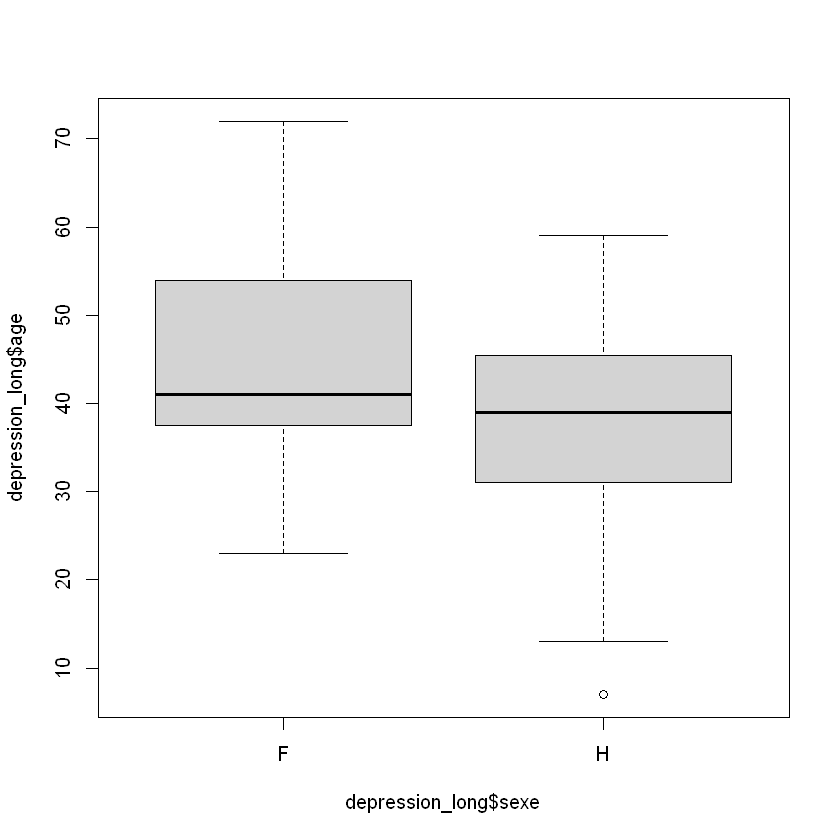

In [21]:
# 1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.

age_homme=depression_long$age[depression_long$sexe=="H"]
age_femme=depression_long$age[depression_long$sexe=="F"]

length(age_homme)
length(age_femme)

# Statistique concernant les hommes
mean(age_homme)
median(age_homme)
sd(age_homme)
quantile(age_homme,0.25)
quantile(age_homme,0.75)

# Statistique concernant les femmes
mean(age_femme)
median(age_femme)
sd(age_femme)
quantile(age_femme,0.25)
quantile(age_femme,0.75)

# 2. Représenter graphiquement ces 2 groupes.
boxplot(depression_long$age~depression_long$sexe)

# 3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.

##### Hommes

## IC hommes n> 30 pas de condition

### IC à 95%

CI(age_homme,0.95)

### IC à 98%
CI(age_homme,0.98)

##### Femmes

## IC femmes n< 30 condition

shapiro.test(age_femme)

### IC à 95%

CI(age_femme,0.95)

### IC à 98%
CI(age_femme,0.98)

# 4. Qu’en concluez-vous ?

En utilisant ce nouveau tableau, pour l'âge des 2 groupes d'urbanisation :

1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.
2. Représenter graphiquement ces 2 groupes.
3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.
4. Qu’en concluez-vous ?


[1] 47

[1] 48

[1] 37.66667

[1] 38

[1] 10.24037

...

75% 
 46

inf      sup 
34.69317 40.64016

inf      sup 
34.10696 41.22637

inf      sup 
35.57946 42.59075

inf      sup 
34.88754 43.28267

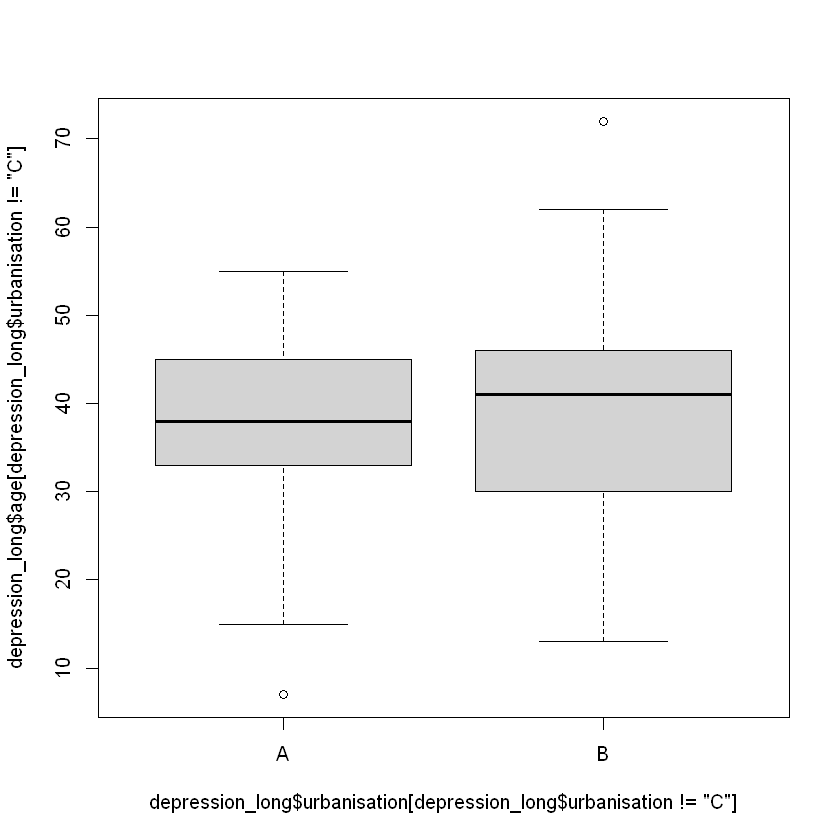

In [22]:
# 1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.

age_A=depression_long$age[depression_long$urbanisation=="A"]
age_B=depression_long$age[depression_long$urbanisation=="B"]

length(age_B)
length(age_A)

# Statistique concernant les A
mean(age_A)
median(age_A)
sd(age_A)
quantile(age_A,0.25)
quantile(age_A,0.75)

# Statistique concernant les B
mean(age_B)
median(age_B)
sd(age_B)
quantile(age_B,0.25)
quantile(age_B,0.75)

# 2. Représenter graphiquement ces 2 groupes.
boxplot(depression_long$age[depression_long$urbanisation!="C"]~depression_long$urbanisation[depression_long$urbanisation!="C"])

# 3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.

##### Hommes

## IC A n> 30 pas de condition

### IC à 95%

CI(age_A,0.95)

### IC à 98%
CI(age_A,0.98)

##### B

## IC femmes n > 30 pas de condition

### IC à 95%

CI(age_B,0.95)

### IC à 98%
CI(age_B,0.98)

# 4. Qu’en concluez-vous ?

En utilisant ce nouveau tableau, pour le score Hamilton des hommes et des femmes :

1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.
2. Représenter graphiquement ces 2 groupes.
3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.
4. Qu’en concluez-vous ?

[1] 84

[1] 16

[1] 30.7619

[1] 30

[1] 8.387626

...

inf      sup 
28.94168 32.58213

inf      sup 
28.59102 32.93278


	Shapiro-Wilk normality test

data:  hamilton_femme
W = 0.88892, p-value = 0.05356


inf      sup 
31.58961 41.16039

inf      sup 
30.53208 42.21792

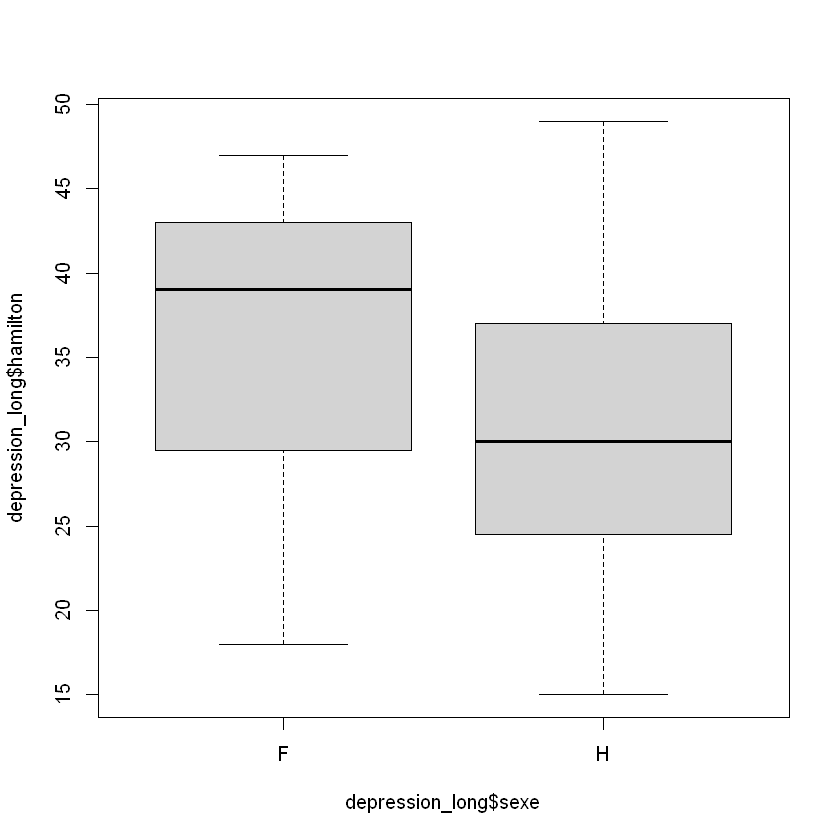

In [23]:
# 1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.

hamilton_homme=depression_long$hamilton[depression_long$sexe=="H"]
hamilton_femme=depression_long$hamilton[depression_long$sexe=="F"]

length(hamilton_homme)
length(hamilton_femme)

# Statistique concernant les hommes
mean(hamilton_homme)
median(hamilton_homme)
sd(hamilton_homme)
quantile(hamilton_homme,0.25)
quantile(hamilton_homme,0.75)

# Statistique concernant les femmes
mean(hamilton_femme)
median(hamilton_femme)
sd(hamilton_femme)
quantile(hamilton_femme,0.25)
quantile(hamilton_femme,0.75)

# 2. Représenter graphiquement ces 2 groupes.
boxplot(depression_long$hamilton~depression_long$sexe)

# 3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.

##### Hommes

## IC hommes n> 30 pas de condition

### IC à 95%

CI(hamilton_homme,0.95)

### IC à 98%
CI(hamilton_homme,0.98)

##### Femmes

## IC femmes n< 30 condition

shapiro.test(hamilton_femme)

### IC à 95%

CI(hamilton_femme,0.95)

### IC à 98%
CI(hamilton_femme,0.98)

# 4. Qu’en concluez-vous ?

En utilisant ce nouveau tableau, pour le score Hamilton des 2 groupes d'urbanisation :

1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.
2. Représenter graphiquement ces 2 groupes.
3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.
4. Qu’en concluez-vous ?


[1] 48

[1] 47

[1] 27.41667

[1] 26.5

[1] 7.695905

...

75% 
41.5

inf      sup 
25.18201 29.65132

inf      sup 
24.74146 30.09188

inf      sup 
32.31915 36.53192

inf      sup 
31.90340 36.94766

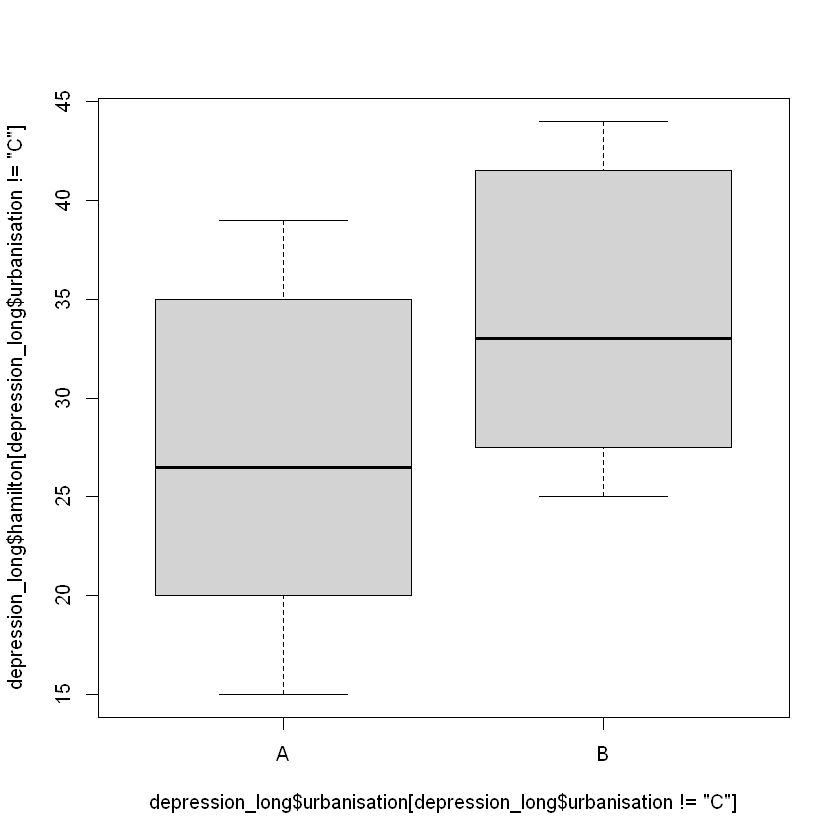

In [24]:
# 1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.

hamilton_A=depression_long$hamilton[depression_long$urbanisation=="A"]
hamilton_B=depression_long$hamilton[depression_long$urbanisation=="B"]

length(hamilton_A)
length(hamilton_B)

# Statistique concernant les A
mean(hamilton_A)
median(hamilton_A)
sd(hamilton_A)
quantile(hamilton_A,0.25)
quantile(hamilton_A,0.75)

# Statistique concernant les B
mean(hamilton_B)
median(hamilton_B)
sd(hamilton_B)
quantile(hamilton_B,0.25)
quantile(hamilton_B,0.75)

# 2. Représenter graphiquement ces 2 groupes.
boxplot(depression_long$hamilton[depression_long$urbanisation!="C"]~depression_long$urbanisation[depression_long$urbanisation!="C"])

# 3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.

##### A

## IC hommes n> 30 pas de condition

### IC à 95%

CI(hamilton_A,0.95)

### IC à 98%
CI(hamilton_A,0.98)

##### B

## IC femmes n> 30 pas de condition

### IC à 95%

CI(hamilton_B,0.95)

### IC à 98%
CI(hamilton_B,0.98)

# 4. Qu’en concluez-vous ?

En utilisant ce nouveau tableau, pour le poids des hommes et des femmes : 
1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.
2. Représenter graphiquement ces 2 groupes.
3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.
4. Qu’en concluez-vous ?

[1] 84

[1] 16

[1] 87.63095

[1] 86

[1] 8.295419

...

25% 
69.25

75% 
 74

inf      sup 
85.83074 89.43117

inf      sup 
85.48394 89.77797


	Shapiro-Wilk normality test

data:  poids_femme
W = 0.81692, p-value = 0.00461


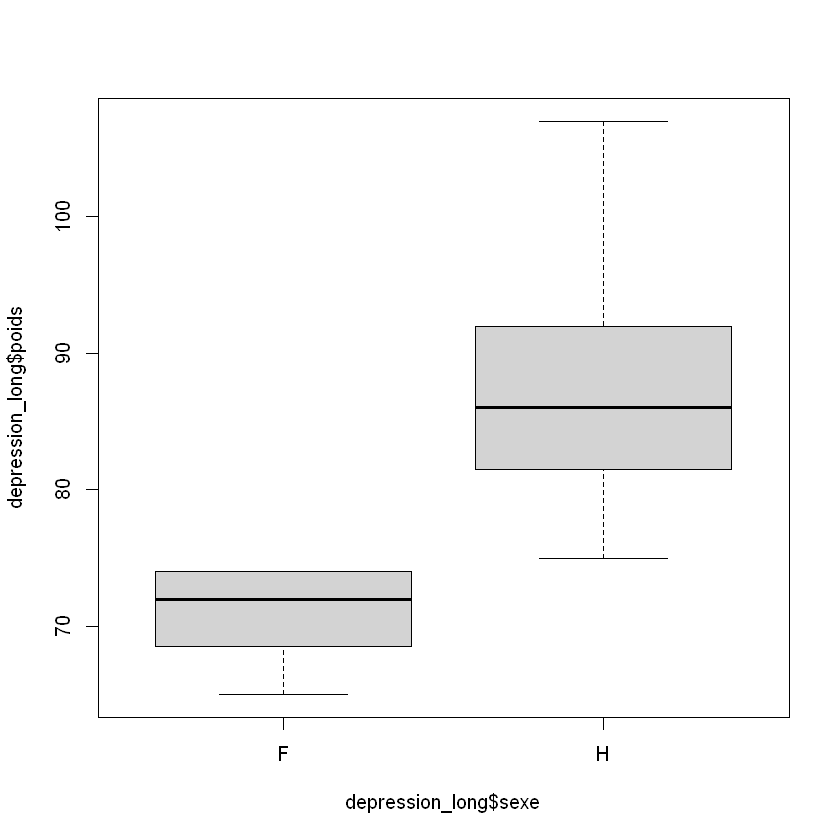

In [25]:
# 1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.

poids_homme=depression_long$poids[depression_long$sexe=="H"]
poids_femme=depression_long$poids[depression_long$sexe=="F"]

length(poids_homme)
length(poids_femme)

# Statistique concernant les hommes
mean(poids_homme)
median(poids_homme)
sd(poids_homme)
quantile(poids_homme,0.25)
quantile(poids_homme,0.75)

# Statistique concernant les femmes
mean(poids_femme)
median(poids_femme)
sd(poids_femme)
quantile(poids_femme,0.25)
quantile(poids_femme,0.75)

# 2. Représenter graphiquement ces 2 groupes.
boxplot(depression_long$poids~depression_long$sexe)

# 3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.

##### Hommes

## IC hommes n> 30 pas de condition

### IC à 95%

CI(poids_homme,0.95)

### IC à 98%
CI(poids_homme,0.98)

##### Femmes

## IC femmes n< 30 condition

shapiro.test(poids_femme)

## => on ne peut pas calculer les IC

En utilisant ce nouveau tableau, pour le poids des 2 groupes d'urbanisation :

1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.
2. Représenter graphiquement ces 2 groupes.
3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.
4. Qu’en concluez-vous ?

[1] 47

[1] 48

[1] 85.41667

[1] 83.5

[1] 9.845257

...

75% 
 91

inf      sup 
82.55790 88.27543

inf      sup 
81.99431 88.83902

inf      sup 
81.71186 87.30942

inf      sup 
81.15946 87.86182

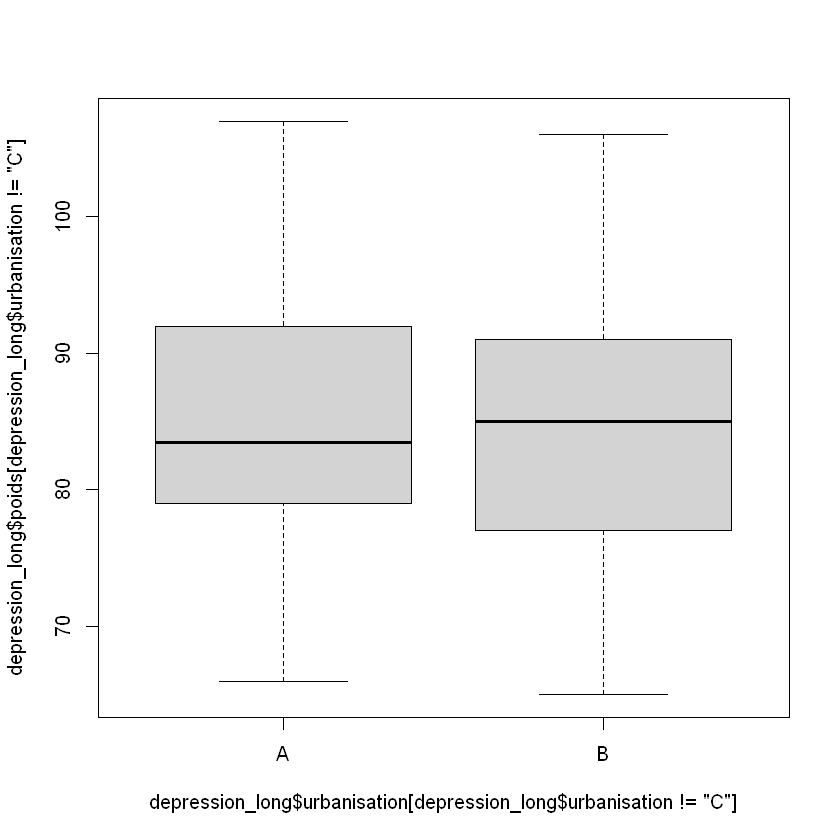

In [26]:
# 1. Calculer la moyenne, la médiane, l'écart type et les quartiles de ces 2 groupes.

poids_A=depression_long$poids[depression_long$urbanisation=="A"]
poids_B=depression_long$poids[depression_long$urbanisation=="B"]

length(poids_B)
length(poids_A)

# Statistique concernant les A
mean(poids_A)
median(poids_A)
sd(poids_A)
quantile(poids_A,0.25)
quantile(poids_A,0.75)

# Statistique concernant les B
mean(poids_B)
median(poids_B)
sd(poids_B)
quantile(poids_B,0.25)
quantile(poids_B,0.75)

# 2. Représenter graphiquement ces 2 groupes.
boxplot(depression_long$poids[depression_long$urbanisation!="C"]~depression_long$urbanisation[depression_long$urbanisation!="C"])

# 3. calculez l'intervalle de confiance de ces 2 groupes à 95% et 98%.

##### Hommes

## IC A n> 30 pas de condition

### IC à 95%

CI(poids_A,0.95)

### IC à 98%
CI(poids_A,0.98)

##### B

## IC femmes n > 30 pas de condition

### IC à 95%

CI(poids_B,0.95)

### IC à 98%
CI(poids_B,0.98)

# 4. Qu’en concluez-vous ?

#### Exercice E

1. Représenter graphiquement les boxplots représentants pour les groupes 1 et 2 :

- a) les scores de Hamilton en séparant les hommes et les femmes.
- b) les âges en séparant les hommes et les femmes.
- c) les poids en séparant les hommes et les femmes.


**sur un seul graphique**

,groupe,hamilton,urbanisation,age,poids,sexe
,<chr>,<int>,<chr>,<int>,<int>,<chr>
1,G1,43,B,57,74,F
2,G2,25,B,48,93,H
3,G1,29,A,37,95,H
4,G2,29,B,41,92,H
5,G1,34,A,7,84,H
6,G2,18,A,30,86,H


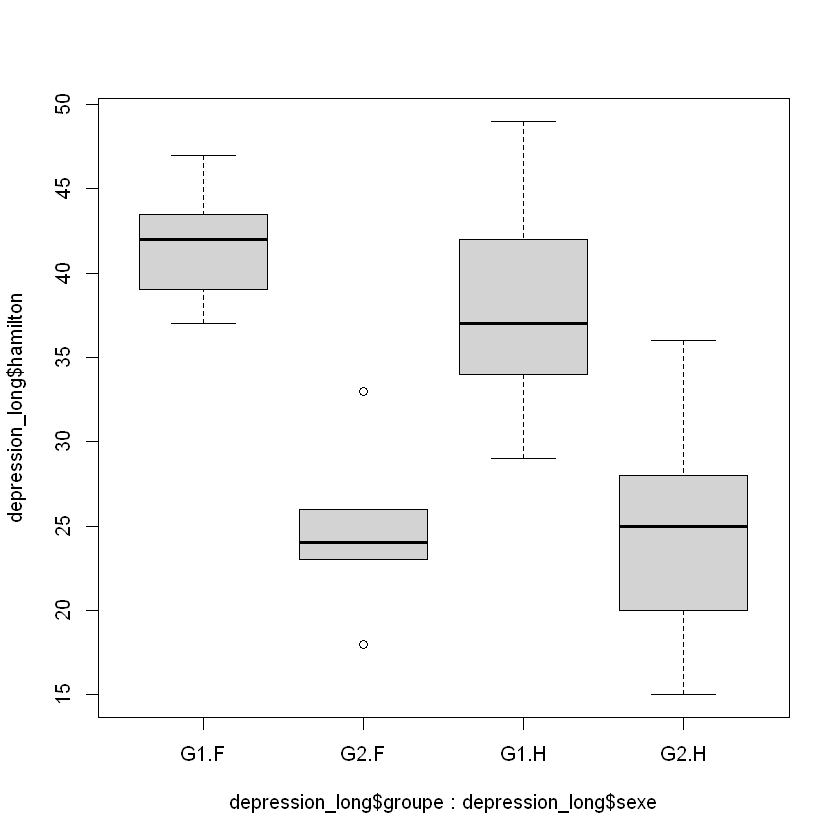

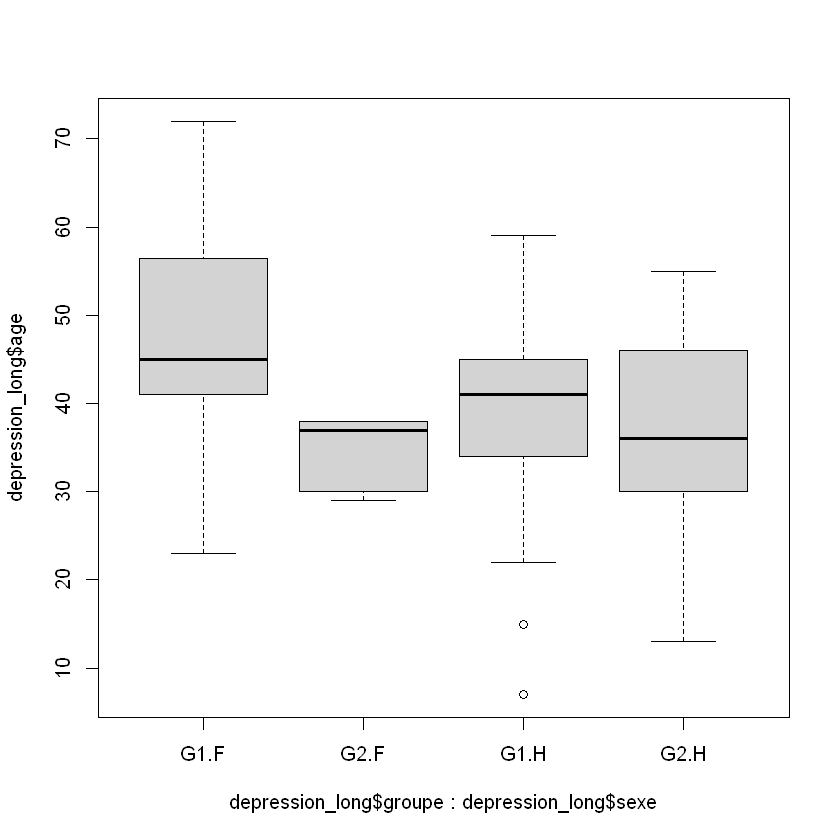

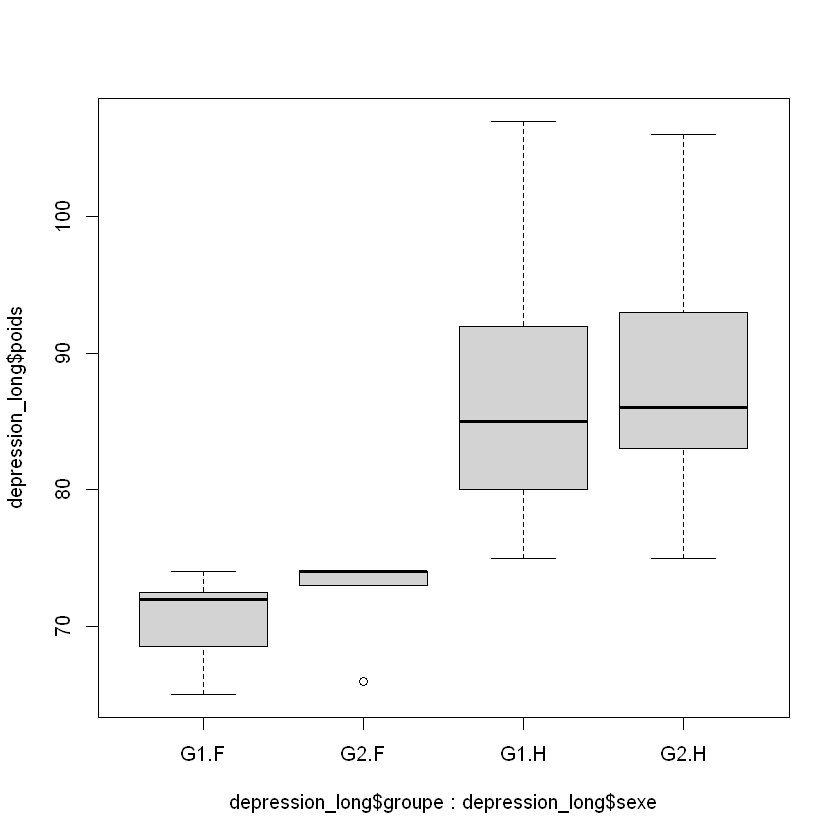

In [27]:
head(depression_long)

# a) les scores de Hamilton en séparant les hommes et les femmes.

boxplot(depression_long$hamilton~depression_long$groupe+depression_long$sexe)

# b) les âges en séparant les hommes et les femmes.

boxplot(depression_long$age~depression_long$groupe+depression_long$sexe)

# c) les pods en séparant les hommes et les femmes.

boxplot(depression_long$poids~depression_long$groupe+depression_long$sexe)


2. Représenter graphiquement le score Hamilton en fonction de l'âge pour les 2 groupes. Vous devez utiliser la fonction `plot()` qui permet de représenter un nuage de point et prend comme deux premiers arguments les données de l'axe des abscisses et celles de l'axe des ordonnées. Vous pouvez leur donner une couleur différente avec l'argument `col=`.

**sur un seul graphique** (je vous conseille d'utiliser le tableau `depression_long`)

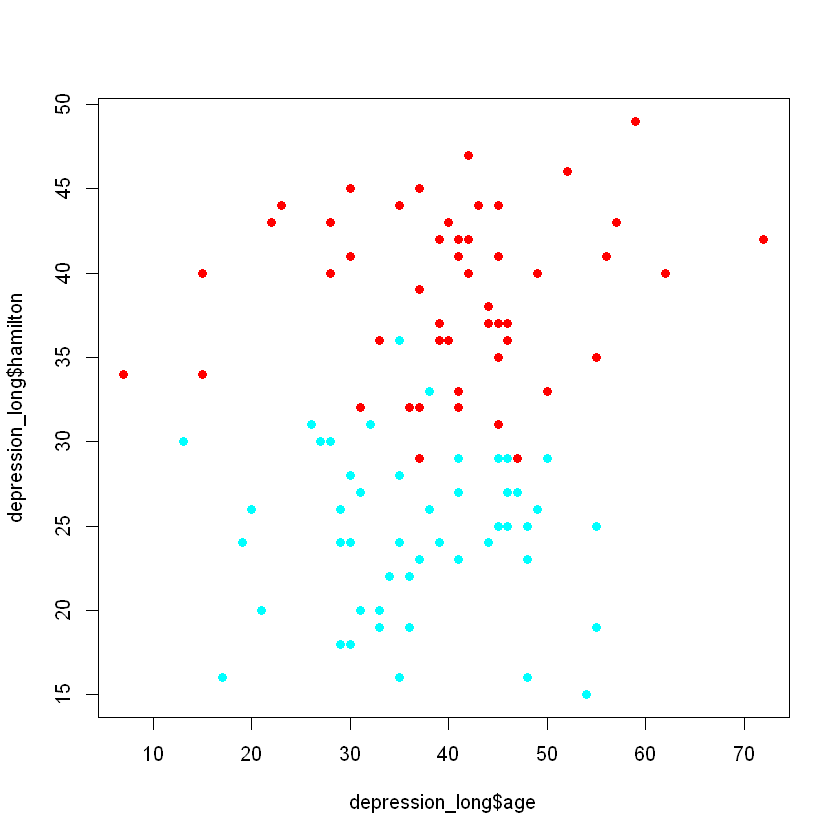

In [28]:
zfac <- factor(depression_long$groupe)

mescouleurs <- rainbow(length(levels(zfac)))

plot(depression_long$age,depression_long$hamilton,col = mescouleurs[zfac],pch = 19)

